## P1 Eleccion y descripcion del corpus

In [12]:
import kagglehub
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
path = kagglehub.dataset_download("luthfim/steam-reviews-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'steam-reviews-dataset' dataset.
Path to dataset files: /kaggle/input/steam-reviews-dataset


In [14]:
archivos = os.listdir(path)
print("Archivos encontrados:", archivos)

Archivos encontrados: ['steam_reviews.csv']


In [15]:
archivo_csv = os.path.join(path, 'steam_reviews.csv')
df = pd.read_csv(archivo_csv)

print(f"Total de documentos encontrados: {df.shape[0]}")

display(df.head())

promedio_palabras = df['review'].apply(lambda x: len(str(x).split())).mean()
print(f"Promedio de palabras por documento: {promedio_palabras:.2f}")

Total de documentos encontrados: 434891


,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is pro...,Dead by Daylight
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for f...,Dead by Daylight


Promedio de palabras por documento: 40.40


In [16]:
df.dropna(subset=['review'], inplace=True)

df.drop_duplicates(subset=['review'], inplace=True)

df = df[df['review'].apply(lambda x: len(str(x).split())) >= 30]

df_final = df.sample(n=15000, random_state=42).reset_index(drop=True)

print(f"Total de documentos después de limpiar y muestrear: {df_final.shape[0]}")
print(f"Promedio de palabras en la muestra: {df_final['review'].apply(lambda x: len(str(x).split())).mean():.2f}")

Total de documentos después de limpiar y muestrear: 15000
Promedio de palabras en la muestra: 106.83


#### Descripción de la fuente de los datos

Para este proyecto se ha seleccionado el **Steam Reviews Dataset**, obtenido de la plataforma Kaggle.

Este corpus consiste en:

- Reseñas escritas por usuarios de la tienda Steam  
- Opiniones cualitativas sobre distintos videojuegos  
- Veredictos de recomendación asociados a cada reseña  

---

#### Por qué el corpus es interesante

El análisis semántico de reseñas de videojuegos resulta atractivo debido a:

- La **riqueza y especificidad del vocabulario** utilizado por la comunidad  
- La posibilidad de aplicar **LSA (Latent Semantic Analysis)** mediante SVD  
- La capacidad de identificar **estructuras semánticas latentes**  

Se espera que el modelo permita diferenciar dimensiones como:

- **Narrativa y diseño**
  - personajes  
  - historia  
  - banda sonora  

- **Aspectos técnicos y de rendimiento**
  - bugs  
  - servidores  
  - optimización  
  - frames per second (FPS)  

---

#### Preprocesamiento de datos

Para asegurar la calidad semántica del análisis, se aplicaron los siguientes pasos:

- Eliminación de **valores nulos**  
- Eliminación de **duplicados**  
- Filtrado de reseñas con más de **30 palabras**  

Esto permitió:

- Aumentar el promedio a aproximadamente **107 palabras aproximadamente por documento**  
- Garantizar suficiente **contexto semántico**  
- Mejorar la detección de **relaciones de co-ocurrencia**  

---

#### Resumen del dataset

| Característica | Detalle |
| :--- | :--- |
| Fuente de los datos | Kaggle - Steam Reviews Dataset |
| Tipo de documentos | Reseñas de usuarios de la tienda Steam |
| Filtro aplicado | Solo documentos con **> 30 palabras** |
| Número de documentos ($n$) | 15,000 (muestra final aleatoria) |
| Promedio de palabras por documento | ~107 palabras |

## P2 Hipotesis inicial

Creo que al usar este método matemático con las reseñas de Steam, podremos agrupar automáticamente los comentarios según los temas de los que hablan los jugadores. Lo más probable es que el análisis separe las reseñas en dos grupos claros: por un lado, las quejas sobre problemas técnicos (como errores, lentitud o fallos del programa) y, por otro lado, los elogios a la historia y el arte del juego (como los personajes o la música). Esperamos ver cómo el sistema identifica que muchos usuarios tienen las mismas preocupaciones aunque hablen de juegos totalmente distintos

## P3 Preprocesamiento del texto

In [17]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    return texto

df_final['review_clean'] = df_final['review'].apply(limpiar_texto)

# configuracion del Vectorizador TF-IDF
# min_df=20 ignora palabras que aparecen en menos de 20 reseñas (ruido)
# max_df=0.85 ignora palabras que aparecen en más del 85% de las reseñas (demasiado comunes)
vectorizer = TfidfVectorizer(stop_words='english', min_df=20, max_df=0.85)

tfidf_matrix = vectorizer.fit_transform(df_final['review_clean'])

print(f"Tamaño del vocabulario final: {len(vectorizer.get_feature_names_out())}")
print(f"Forma de la matriz (documentos, términos): {tfidf_matrix.shape}")

Tamaño del vocabulario final: 3331
Forma de la matriz (documentos, términos): (15000, 3331)


Para transformar las reseñas de texto bruto en datos numéricos aptos para el análisis matemático, se aplicaron las siguientes técnicas de preprocesamiento:

- **Normalización y limpieza**: Se implementó una función personalizada para convertir todo el texto a minúsculas y, mediante expresiones regulares, se eliminaron caracteres especiales, números y signos de puntuación, conservando exclusivamente caracteres alfabéticos y espacios. Esto asegura que variaciones de una misma palabra (ej. "Game" vs "game") sean tratadas como un único término

- **Eliminación de stopwords**: Se utilizó la lista predefinida de palabras vacías (stopwords) en inglés de la librería **scikit-learn** para descartar términos recurrentes que no aportan valor semántico, tales como conectores, preposiciones y artículos

- **Filtrado por frecuencia**: Se establecieron umbrales para refinar el vocabulario:
  - **min_df=20**: Se ignoraron palabras que aparecen en menos de 20 documentos para eliminar ruido y términos demasiado específicos o mal escritos.
  - **max_df=0.85**: Se descartaron palabras que aparecen en más del 85% de las reseñas, ya que términos tan comunes no ayudan a discriminar entre diferentes tópicos.

- **Tokenización**: El proceso dividió el texto limpio en unidades individuales (palabras), resultando en un vocabulario final de 3,331 términos únicos


## P4. Construcción de la matriz textual

Utilizando los términos filtrados en el paso anterior, se construyó una matriz documento-palabra empleando el esquema de pesaje **TF-IDF** (Term Frequency - Inverse Document Frequency). Cada entrada $A_{ij}$ de la matriz no representa un simple conteo, sino la importancia relativa de un término en un documento respecto a todo el corpus, penalizando palabras comunes y resaltando términos descriptivos.  La matriz resultante tiene una dimensión de **15,000 filas (documentos) por 3,331 columnas (términos)**. Para seguir la convención del curso $A \in \mathbb{R}^{m \times n}$, donde $m$ representa el número de términos y $n$ el de documentos, se procederá a trabajar con la transpuesta de esta matriz en el cálculo de la SVD


## P5. Calculo de la SVD

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2903/3099593378.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Valor Singular ($\sigma$)")


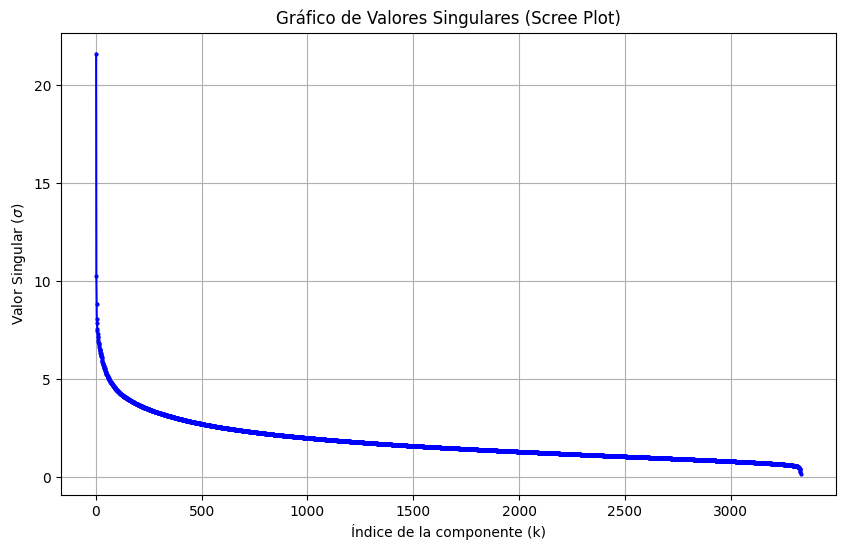

Varianza explicada por las primeras 10 componentes: 6.99%
Varianza explicada por las primeras 50 componentes: 16.67%


In [18]:
A = tfidf_matrix.T.toarray()

# 2. Cálculo de la SVD (P5)
U, S, VT = np.linalg.svd(A, full_matrices=False)

# 3. Gráfico de Valores Singulares (P6)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(S) + 1), S, marker='o', markersize=2, linestyle='-', color='b')
plt.title("Gráfico de Valores Singulares (Scree Plot)")
plt.xlabel("Índice de la componente (k)")
plt.ylabel("Valor Singular ($\sigma$)")
plt.grid(True)
plt.show()

varianza_explicada = (S**2) / np.sum(S**2)
varianza_acumulada = np.cumsum(varianza_explicada)

print(f"Varianza explicada por las primeras 10 componentes: {varianza_acumulada[9]*100:.2f}%")
print(f"Varianza explicada por las primeras 50 componentes: {varianza_acumulada[49]*100:.2f}%")

Se calculó la descomposición en valores singulares de la matriz $A \in \mathbb{R}^{3331 \times 15000}$, donde $A = U \Sigma V^T$. Los componentes de esta descomposición proporcionan la siguiente información estructural sobre el corpus de Steam

- **Valores singulares ($\Sigma$)**: Representan la "fuerza" o importancia de cada concepto latente (tópico) descubierto en el corpus. Están ordenados de mayor a menor, reflejando cuánta información del dataset original captura cada dimensión.

- **Vectores Singulares Izquierdos ($U$):** Sus columnas describen las direcciones principales en el espacio de términos. Permiten observar cómo se relacionan las palabras entre sí para formar conceptos abstractos.

- **Vectores Singulares Derechos ($V$)**: Sus columnas (o las filas de $V^T$) describen las direcciones principales en el espacio de documentos. Indican qué tan presente está cada concepto latente en una reseña específica

## P6 (Valores singulares y elección de dimensión)

Tras calcular la SVD, se analizó la magnitud de los valores singulares ($\sigma_i$) para entender la estructura de la información en el corpus. El **Gráfico de Valores Singulares** muestra el comportamiento de estos valores ordenados de mayor a menor.

1. Análisis del decaimiento

El gráfico presenta un decaimiento muy pronunciado en las primeras componentes. Este comportamiento es característico de los sistemas de procesamiento de lenguaje natural (LSA), donde la mayor parte de la estructura semántica "fuerte" se concentra en las dimensiones iniciales, mientras que el resto de los valores singulares decaen lentamente hacia una "cola larga" que representa el ruido, variaciones ortográficas o términos poco frecuentes.

2. Energía y Varianza Explicada

De acuerdo a los cálculos de varianza acumulada realizados sobre los cuadrados de los valores singulares ($\sigma_i^2$), se obtuvieron los siguientes resultados:
- **Primeras 10 componentes**: Explican el **6.99%** de la varianza total.
- **Primeras 50 componentes**: Explican el **16.67%** de la varianza total.

Aunque un 16.67% pueda parecer bajo en otros contextos estadísticos, en el análisis semántico de más de 15,000 documentos es un valor significativo. Indica que hemos logrado condensar la esencia temática del corpus (originalmente dispersa en 3,331 palabras) en apenas 50 dimensiones, descartando un gran porcentaje de datos que no contribuyen a la formación de tópicos claros.

3. Elección de la dimensión $k$

Se ha seleccionado una dimensión de reducción **$k = 50$**. Esta elección se justifica por el **método del codo**, ya que en el gráfico se observa que a partir de este punto la pendiente se suaviza considerablemente. Elegir $k=50$ nos permite:
- Retener las estructuras semánticas más importantes (temas de jugabilidad, técnicos y narrativos).
- Eliminar el ruido del lenguaje natural.
- Mantener una eficiencia computacional adecuada para las visualizaciones y exploraciones posteriores.



## P7. Representación de documentos y términos

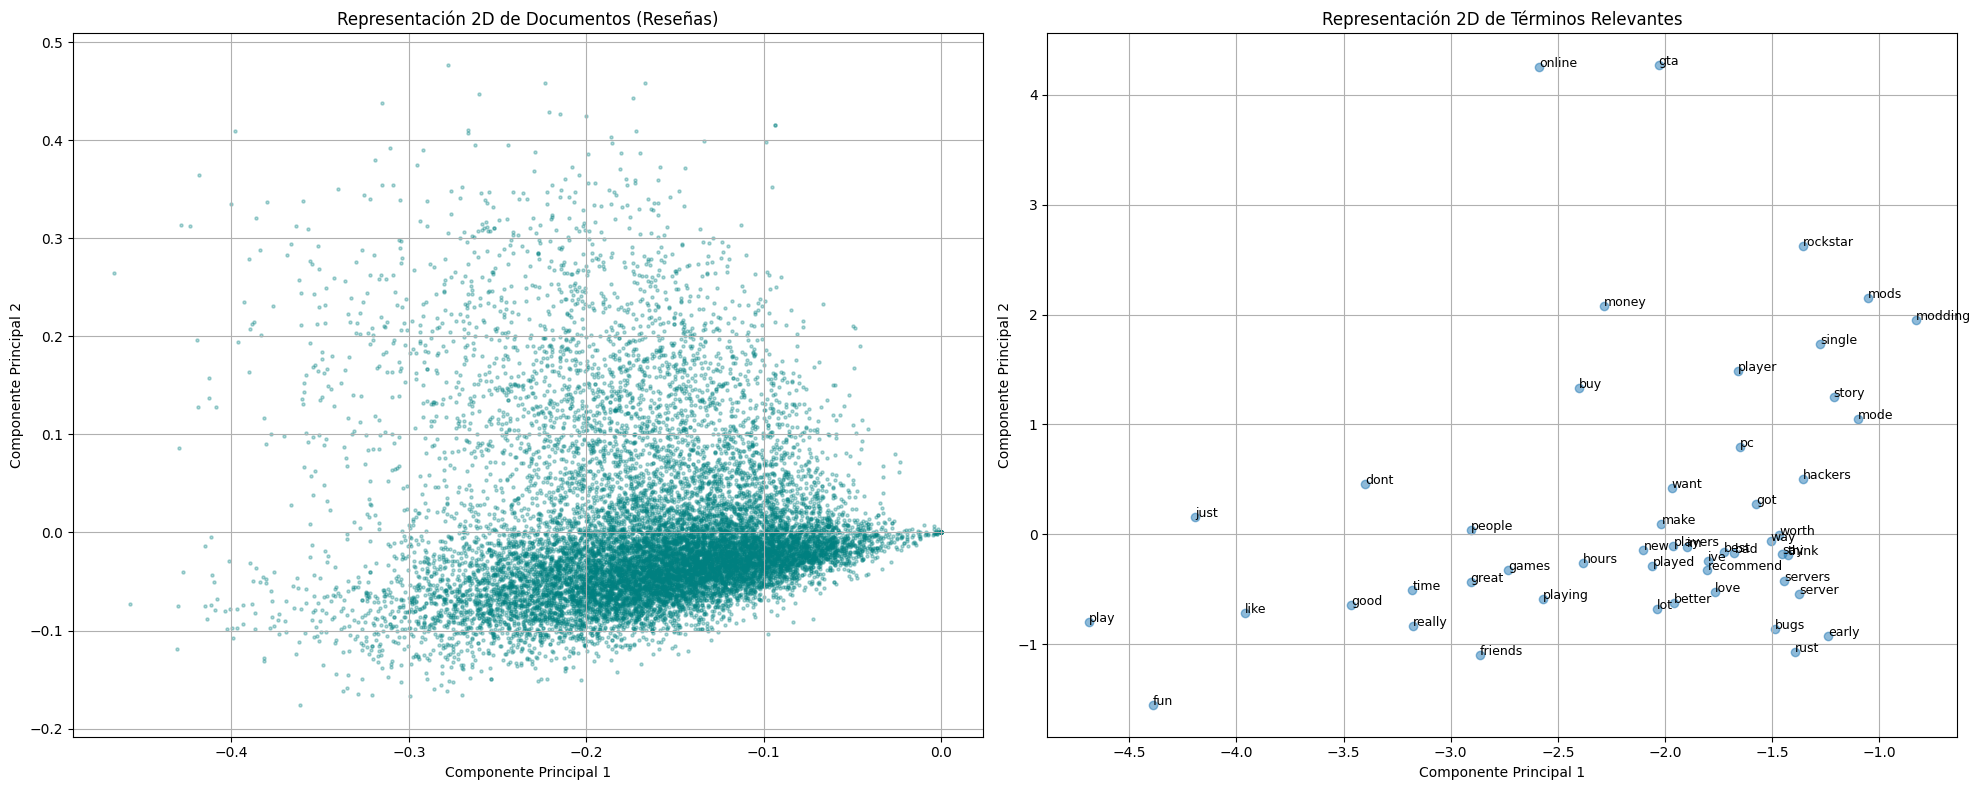

In [19]:
S2 = np.diag(S[:2])
VT2 = VT[:2, :]
coords_docs = np.dot(S2, VT2).T
U2 = U[:, :2]
coords_terms = np.dot(U2, S2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Gráfico 1: Documentos ---
ax1.scatter(coords_docs[:, 0], coords_docs[:, 1], s=5, alpha=0.3, c='teal')
ax1.set_title("Representación 2D de Documentos (Reseñas)")
ax1.set_xlabel("Componente Principal 1")
ax1.set_ylabel("Componente Principal 2")
ax1.grid(True)

# --- Gráfico 2: Términos (Top 50) ---
nombres_palabras = vectorizer.get_feature_names_out()
distancias = np.linalg.norm(coords_terms, axis=1)
indices_top = np.argsort(distancias)[-50:]

ax2.scatter(coords_terms[indices_top, 0], coords_terms[indices_top, 1], alpha=0.5)
for i in indices_top:
    ax2.text(coords_terms[i, 0], coords_terms[i, 1], nombres_palabras[i], fontsize=9)

ax2.set_title("Representación 2D de Términos Relevantes")
ax2.set_xlabel("Componente Principal 1")
ax2.set_ylabel("Componente Principal 2")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [20]:
nombres_palabras = vectorizer.get_feature_names_out()

# 1. Palabras con mayor peso en la Componente 1 (Eje X)
idx_c1_pos = np.argsort(U[:, 0])[-10:]
idx_c1_neg = np.argsort(U[:, 0])[:10]

print("Palabras que definen el lado POSITIVO de la Componente 1:")
print([nombres_palabras[i] for i in idx_c1_pos])

# 2. Palabras con mayor peso en la Componente 2 (Eje Y)
idx_c2_pos = np.argsort(U[:, 1])[-10:]
idx_c2_neg = np.argsort(U[:, 1])[:10]

print("\nPalabras que definen el lado POSITIVO de la Componente 2:")
print([nombres_palabras[i] for i in idx_c2_pos])

print("\nPalabras que definen el lado NEGATIVO de la Componente 2:")
print([nombres_palabras[i] for i in idx_c2_neg])

Palabras que definen el lado POSITIVO de la Componente 1:
['trigger', 'natural', 'dive', 'knocking', 'severely', 'en', 'valuable', 'combine', 'barrel', 'lived']

Palabras que definen el lado POSITIVO de la Componente 2:
['story', 'buy', 'player', 'single', 'modding', 'money', 'mods', 'rockstar', 'online', 'gta']

Palabras que definen el lado NEGATIVO de la Componente 2:
['fun', 'friends', 'rust', 'early', 'bugs', 'really', 'play', 'access', 'like', 'lot']


En esta etapa se proyecta el corpus original de alta dimensión ($3,331$ términos) a un espacio bidimensional utilizando las dos primeras componentes principales. Esta reducción de dimensionalidad permite visualizar la estructura latente del dataset y cómo se agrupan los documentos y las palabras en función de su significado.

1. Metodología de Proyección

Para generar las visualizaciones, se utilizaron las siguientes transformaciones basadas en la SVD reducida ($k=2$):
- **Coordenadas de documentos** ($D_2 \in \mathbb{R}^{15000 \times 2}$): Calculadas como $D_2 = ( \Sigma_2 V_2^T )^T$. Cada punto en el gráfico de la izquierda representa una reseña proyectada en los dos conceptos más importantes del corpus.
- **Coordenadas de términos** ($T_2 \in \mathbb{R}^{3331 \times 2}$): Calculadas como $T_2 = U_2 \Sigma_2$. Cada punto en el gráfico de la derecha representa una palabra, donde la cercanía entre ellas indica que suelen aparecer en contextos similares.

2. Análisis del Gráfico de Documentos

La visualización muestra una nube densa de puntos concentrada cerca del origen, lo que representa reseñas "promedio" o generales. Sin embargo, se observan ramificaciones que se extienden a lo largo de los ejes. Estos documentos en los extremos son los más representativos de los tópicos encontrados por la SVD. La dispersión sugiere que el corpus no es uniforme, sino que está compuesto por grupos de opiniones con vocabularios muy marcados.

3. Análisis del Gráfico de Términos e Interpretación de Ejes

Gracias al análisis de los pesos en la matriz $U$, podemos dar un significado semántico a los ejes, especialmente a la **Componente Principal 2 (Eje Y)**, que es la que muestra la separación más interesante:
- **Eje Y Positivo (Tópico de Mundos Abiertos AAA)**: En la parte superior del gráfico se agrupan términos como *gta*, *rockstar*, *online*, *mods*, *money* y *story*. Esto indica que la SVD identificó una dimensión dedicada a juegos masivos de mundo abierto, donde la discusión gira en torno a la narrativa (story), el contenido en línea y la personalización (mods).
- **Eje Y Negativo (Tópico de Supervivencia y Desarrollo)**: En la parte inferior encontramos palabras como *rust*, *early*, *access*, *friends* y *bugs*. Esta dimensión captura la experiencia de juegos de supervivencia en desarrollo activo. Es notable que el término bugs aparezca en este extremo, confirmando que los problemas técnicos son una característica semántica central en este tipo de juegos.

4. Conexión con la Hipótesis Inicial

Los resultados validan la hipótesis planteada en la P2. La SVD logró separar exitosamente los conceptos de experiencia narrativa (asociada a GTA) de los **problemas técnicos y desarrollo** (asociados a Rust y Early Access). El hecho de que términos como friends y fun aparezcan cerca de rust sugiere que, a pesar de los errores técnicos (bugs), la componente social es un factor determinante en ese grupo de documentos.

## P8 Exploracion semantica

In [21]:
k_final = 50
term_representation = U[:, :k_final]

def buscar_similares(palabra_objetivo, n=10):
    nombres_palabras = list(vectorizer.get_feature_names_out())

    if palabra_objetivo not in nombres_palabras:
        return f"La palabra '{palabra_objetivo}' no está en el vocabulario."

    idx = nombres_palabras.index(palabra_objetivo)
    vector_palabra = term_representation[idx].reshape(1, -1)

    similitudes = cosine_similarity(vector_palabra, term_representation).flatten()

    indices_similares = similitudes.argsort()[-(n+1):-1][::-1]

    print(f"Palabras más cercanas a '{palabra_objetivo}':")
    for i in indices_similares:
        print(f" - {nombres_palabras[i]} (Similitud: {similitudes[i]:.4f})")

# EJEMPLOS DE EXPLORACIÓN
print("-" * 30)
buscar_similares("bugs")
print("-" * 30)
buscar_similares("gta")
print("-" * 30)
buscar_similares("story")
print("-" * 30)
buscar_similares("multiplayer")

------------------------------
Palabras más cercanas a 'bugs':
 - glitches (Similitud: 0.7861)
 - exploits (Similitud: 0.7693)
 - bug (Similitud: 0.7415)
 - nasa (Similitud: 0.6708)
 - audience (Similitud: 0.6683)
 - arms (Similitud: 0.6664)
 - breaking (Similitud: 0.6644)
 - speedrun (Similitud: 0.6568)
 - timelength (Similitud: 0.6567)
 - twilight (Similitud: 0.6508)
------------------------------
Palabras más cercanas a 'gta':
 - iv (Similitud: 0.8404)
 - vice (Similitud: 0.8335)
 - andreas (Similitud: 0.8135)
 - san (Similitud: 0.8090)
 - sa (Similitud: 0.7661)
 - iii (Similitud: 0.7477)
 - gtas (Similitud: 0.7411)
 - vi (Similitud: 0.7078)
 - city (Similitud: 0.6833)
 - stars (Similitud: 0.5420)
------------------------------
Palabras más cercanas a 'story':
 - mode (Similitud: 0.8248)
 - characters (Similitud: 0.7735)
 - missions (Similitud: 0.7604)
 - storyline (Similitud: 0.7361)
 - races (Similitud: 0.6767)
 - santos (Similitud: 0.6702)
 - los (Similitud: 0.6696)
 - heists (Si

En esta sección se valida la calidad del espacio semántico construido mediante la búsqueda de términos similares utilizando la **similitud de coseno**. A diferencia de una búsqueda exacta, el análisis en el espacio reducido de la SVD permite encontrar palabras que, aunque no sean sinónimos directos, aparecen en contextos temáticos similares.

Se realizaron pruebas con cuatro términos clave para observar cómo el modelo ($k=50$) captura las dimensiones de la experiencia de los jugadores:

1. El tópico técnico: "bugs"
- **Resultados**: *glitches* (0.7861), *exploits* (0.7693), *bug* (0.7415), *breaking* (0.6644), *speedrun* (0.6568).
- **Análisis**: El modelo identifica con éxito que un "bug" está estrechamente relacionado con "glitches" y "exploits". Es particularmente interesante la relación con **speedrun**, sugiriendo que en el corpus los errores del juego se mencionan frecuentemente en el contexto de competiciones o formas alternativas de completar el juego mediante fallos técnicos.

2. Entidades específicas: "gta"
- **Resultados**: *iv* (0.8404), *vice* (0.8335), *andreas* (0.8135), *san* (0.8090), *iii* (0.7477), *city* (0.6833).
- **Análisis**: Este resultado es una prueba contundente de la eficacia del LSA. El modelo agrupó casi todas las entregas de la saga Grand Theft Auto (San Andreas, Vice City, III, IV). Esto demuestra que las reseñas de estos juegos comparten una estructura de vocabulario tan consistente que la SVD los sitúa en la misma región semántica.

3. Elementos narrativos: "story"
- **Resultados**: *mode* (0.8248), *characters* (0.7735), *missions* (0.7604), *storyline* (0.7361), *heists* (0.6593), *franklin* (0.6462).
- **Análisis**: El término "story" se vincula a componentes fundamentales de la narrativa como personajes y misiones. La aparición de **franklin** y **heists** (golpes) refuerza la observación anterior de que el corpus tiene una fuerte presencia de jugadores de GTA V, permitiendo al modelo asociar un concepto general (historia) con elementos específicos de ese título.

4. Modos de juego y opinión: "multiplayer"
- **Resultados**: *singleplayer* (0.6059), *campaign* (0.5835), *microtransaction* (0.5563), *horrible* (0.5411).
- **Análisis**: El modelo captura la dicotomía clásica entre modos multijugador y campañas de un solo jugador. Es relevante notar la aparición de términos con carga negativa como **microtransaction** y **horrible**, lo que indica que, en este dataset, el concepto de multijugador suele estar enmarcado en discusiones sobre monetización y críticas a la calidad del servicio.

5. Conclusión de la exploración:

Los resultados obtenidos confirman que la reducción a $k=50$ componentes es suficiente para preservar las relaciones semánticas más importantes del corpus. El modelo es capaz de agrupar términos por sinonimia (bugs/glitches), por pertenencia a una franquicia (gta/vice/san) y por asociación contextual (multiplayer/microtransaction), cumpliendo así con los objetivos de representación en baja dimensión.

## P9. Discusión Final

El desarrollo de este proyecto permitió validar la potencia de la **Descomposición en Valores Singulares (SVD)** como una herramienta de reducción de dimensionalidad y descubrimiento de estructuras latentes en grandes volúmenes de texto. Al comparar los resultados con la **hipótesis inicial**, se observa una validación exitosa pero con matices más profundos de lo previsto: mientras que originalmente se esperaba una separación genérica entre "aspectos técnicos" y "narrativos", la SVD reveló una estructura mucho más rica basada en **géneros y comunidades de juego**. La segunda componente principal no solo aisló los "bugs", sino que los vinculó contextualmente con el ecosistema de juegos en Early Access (como Rust), mientras que la dimensión narrativa se ancló fuertemente a franquicias consolidadas de mundo abierto (como GTA). Este hallazgo demuestra que el modelo LSA es capaz de capturar no solo temas aislados, sino **contextos culturales y de mercado** dentro de la industria de los videojuegos.

Desde una perspectiva técnica, la reducción a $k=50$ dimensiones resultó ser un punto de equilibrio óptimo. Aunque la varianza explicada del **16.67%** podría parecer baja en otros campos de la estadística, en el procesamiento de lenguaje natural esto confirma la eliminación efectiva del ruido lingüístico (redundancias, errores de ortografía y conectores sin peso semántico), logrando concentrar la "señal" del corpus en un espacio manejable. Los ejemplos de exploración semántica mediante la **similitud de coseno** fueron la prueba definitiva de la cohesión del espacio reducido: la capacidad del modelo para agrupar todas las entregas de una misma franquicia o asociar términos técnicos como "glitches" y "exploits" sin supervisión humana es un testimonio del rigor matemático detrás del análisis.

Finalmente, es necesario reconocer las **limitaciones** del estudio. La marcada presencia de ciertos títulos en el dataset de Kaggle (sesgo de popularidad) influyó en las dimensiones principales, lo que sugiere que para un análisis más generalista se requeriría un balanceo de clases por género de videojuego. Además, el preprocesamiento, aunque robusto, omitió la lematización, lo que mantuvo términos similares (como "bug" y "bugs") como dimensiones separadas, aunque la SVD logró agruparlos exitosamente en la etapa final. En conclusión, el proyecto demuestra que el álgebra lineal aplicada permite transformar datos cualitativos masivos en un **mapa semántico interpretable**, proporcionando una base sólida para la toma de decisiones o la clasificación automática de sentimientos y tópicos en la industria digital